DAY 4: Fund Performance Analytics

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

In [2]:
# Load cleaned datasets

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/01_fund_master.csv'

In [3]:
import os

print(os.getcwd())

c:\Users\samar\OneDrive\Desktop\MutualFundAnalytics\notebooks


In [4]:
import os

print(os.listdir("../data"))

['processed', 'raw']


In [5]:
print(os.listdir("../data/processed"))

['01_fund_master_clean.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv']


In [6]:
# Load cleaned datasets

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [7]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [10]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


# Task 1

## Daily Return Calculation

Calculate daily returns for every mutual fund.

In [11]:
# Convert date column

nav["date"] = pd.to_datetime(nav["date"])

# Sort values

nav = nav.sort_values(["amfi_code","date"])

# Calculate daily return

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [12]:
# Save daily returns

nav.to_csv("../reports/returns_computed.csv",index=False)

# Task 2

## CAGR Report

In [13]:
# Calculate CAGR

cagr = performance[[
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]]

cagr.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [14]:
cagr.to_csv("../reports/cagr_report.csv",index=False)

# Task 3

## Sharpe Ratio

In [15]:
# Risk-free rate

rf = 0.065

# Standard deviation of returns

sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean","std"])

# Annualized Sharpe Ratio

sharpe["Sharpe"] = ((sharpe["mean"]*252)-rf)/(sharpe["std"]*np.sqrt(252))

sharpe.head()

,mean,std,Sharpe
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [16]:
sharpe.to_csv("../reports/sharpe_values.csv")

# Task 4

## Sortino Ratio

In [17]:
# Negative returns

negative = nav.copy()

negative["downside"] = negative["daily_return"]

negative.loc[negative["downside"]>0,"downside"] = 0

sortino = negative.groupby("amfi_code").agg(
    mean_return=("daily_return","mean"),
    downside_std=("downside","std")
)

sortino["Sortino"] = ((sortino["mean_return"]*252)-rf)/(sortino["downside_std"]*np.sqrt(252))

sortino.head()

,mean_return,downside_std,Sortino
amfi_code,,,
100016,0.000142,0.005163,-0.357702
100025,0.000170,0.001382,-1.009643
100033,0.001080,0.006632,1.967316
101206,0.000852,0.004989,1.889576
101207,0.000424,0.009256,0.285576


In [18]:
sortino.to_csv("../reports/sortino_values.csv")

# Task 5

## Alpha and Beta

In [19]:
# Example benchmark returns

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark["benchmark_return"] = benchmark.groupby("index_name")["close_value"].pct_change()

alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"]==code]

    merged = pd.merge(
        fund,
        benchmark,
        on="date"
    )

    merged = merged.dropna()

    if len(merged)>10:

        slope,intercept,_,_,_ = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta.append([
            code,
            intercept*252,
            slope
        ])

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code","alpha","beta"]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [20]:
alpha_beta.to_csv("../reports/alpha_beta.csv",index=False)

# Task 6

## Maximum Drawdown

In [21]:
drawdown = nav.copy()

drawdown["running_max"] = drawdown.groupby("amfi_code")["nav"].cummax()

drawdown["drawdown"] = drawdown["nav"]/drawdown["running_max"]-1

max_dd = drawdown.groupby("amfi_code")["drawdown"].min()

max_dd.head()

amfi_code
100016   -0.247344
100025   -0.043083
100033   -0.162172
101206   -0.112916
101207   -0.354469
Name: drawdown, dtype: float64

In [22]:
max_dd.to_csv("../reports/max_drawdown.csv")

# Task 7

## Fund Scorecard

In [23]:
scorecard = performance[[
    "scheme_name",
    "return_3yr_pct",
    "expense_ratio_pct"
]]

scorecard.head()

,scheme_name,return_3yr_pct,expense_ratio_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54
1,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77


In [24]:
scorecard.to_csv("../reports/fund_scorecard.csv",index=False)

# Task 8

## Benchmark Comparison

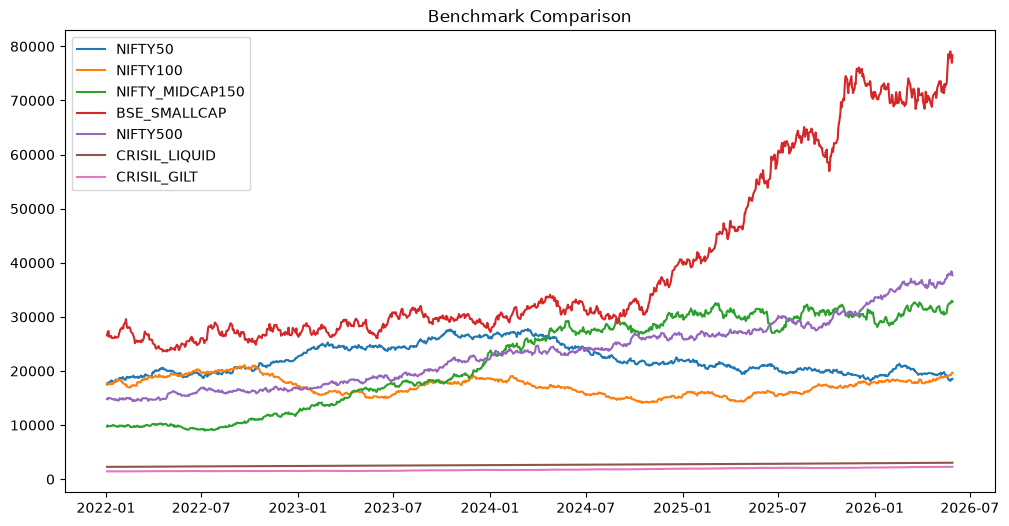

In [25]:
plt.figure(figsize=(12,6))

for name in benchmark["index_name"].unique():

    temp = benchmark[benchmark["index_name"]==name]

    plt.plot(
        temp["date"],
        temp["close_value"],
        label=name
    )

plt.legend()

plt.title("Benchmark Comparison")

plt.savefig("../reports/benchmark_chart.png")

plt.show()